# Caso D · 05 Alertas IAQ con histéresis y jerarquía L1/L2/L3

> _Tutorial · Caso de uso: **D — IAQ + ocupación** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Implementar un sistema de alertas IAQ **jerárquico** (L1/L2/L3) con **histéresis temporal** (sostenido N minutos antes de disparar) y banda de hysteresis (rearme con margen). Cuantificar el efecto de la histéresis sobre la fatiga de alertas.


## 2. Qué se aprende

- Categorización CO₂ por umbrales OMS / EN 16798 (5 niveles).
- **Histéresis temporal**: dispara solo si superado durante ≥ N min.
- **Banda de hysteresis**: rearme con margen para evitar oscilación.
- Jerarquía L1 (profesor) / L2 (conserje) / L3 (dirección + actuador).
- Tabla de tiempo total por categoría (KPI de director de centro).


## 3. Contexto del caso de uso

Sin histéresis, una transición ruidosa por encima de 1 500 ppm dispara decenas de alertas por hora → fatiga → operador desactiva → sistema invisible. Con histéresis (5 min sostenido + banda 100 ppm), las alertas son útiles.


## 4. Relación con CENTINELA+

Las alertas van a `telemetry_events` con tags `level`, `severity`, `asset_id`. Webhook a Mattermost/Slack para L2/L3.


## 5. Relación con Medallion

Oro: reglas con estado + reporte de alertas.


## 6. Datos de entrada

Mock In-Gauge 30 días para tener picos.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

Eventos como measurement separado:

```
captia_event,asset_id=AULA01,level=L1,kind=co2_alert value_ppm=1612.0,severity=2 1715260800000000000
```


## 9. Carga de datos o mock

Cargamos 30 días para tener variabilidad real de CO₂.


In [2]:
df, _ = mocks.make_ingauge_aula01_mock(days=30)
df = df.set_index("timestamp")
print({"filas": len(df), "co2_max": float(df["Indoor_CO2"].max()),
       "co2_p99": float(df["Indoor_CO2"].quantile(0.99))})


{'filas': 43200, 'co2_max': 1353.6, 'co2_p99': 1271.7}


## 10. Exploración paso a paso

Categorización OMS + thresholds por nivel jerárquico.


In [3]:
THRESHOLDS_PPM = {"L1": 800, "L2": 1000, "L3": 1500}  # CO2 ppm — alineados con EN 16798 cat I/II/III
HOLD_MIN = {"L1": 5, "L2": 5, "L3": 10}               # min sostenido
HYST_BAND = 75                                         # ppm para rearme

def cat_co2(x):
    if x < 800: return "optimo"
    if x < 1000: return "aceptable"
    if x < 1500: return "vigilar"
    if x < 2000: return "molesto"
    return "ventilar"

df["co2_cat"] = df["Indoor_CO2"].apply(cat_co2)
dist = df["co2_cat"].value_counts(normalize=True).reindex(
    ["optimo", "aceptable", "vigilar", "molesto", "ventilar"], fill_value=0
).round(3)
print(dist)


co2_cat
optimo       0.842
aceptable    0.062
vigilar      0.096
molesto      0.000
ventilar     0.000
Name: proportion, dtype: float64


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

**Algoritmo con histéresis**: máquina de estados (`armed → triggered → rearming`). Comparamos: (a) sin histéresis (cada punto > umbral), (b) con histéresis (sostenido + banda).


In [4]:
def alerts_naive(series, threshold):
    """Cada punto > threshold genera alerta — sin estado."""
    return (series > threshold).astype(int)

def alerts_hysteresis(series, threshold, hold_min, hyst_band):
    """Máquina de estados con sostenido N min + banda de rearme."""
    sample_min = (series.index[1] - series.index[0]).total_seconds() / 60
    hold_samples = max(1, int(hold_min / sample_min))
    out = pd.Series(0, index=series.index, dtype=int)
    state = "armed"
    above_count = 0
    for ts, v in series.items():
        if state == "armed":
            if v > threshold:
                above_count += 1
                if above_count >= hold_samples:
                    out[ts] = 1
                    state = "triggered"
            else:
                above_count = 0
        elif state == "triggered":
            if v < (threshold - hyst_band):
                state = "armed"
                above_count = 0
    return out

# Comparativa para nivel L2 (1500 ppm)
naive_L2 = alerts_naive(df["Indoor_CO2"], THRESHOLDS_PPM["L2"])
hyst_L2 = alerts_hysteresis(df["Indoor_CO2"], THRESHOLDS_PPM["L2"],
                             HOLD_MIN["L2"], HYST_BAND)
comparison = pd.DataFrame({
    "metodo": ["naive (cada punto)", "hysteresis (10min + 100ppm)"],
    "alertas_totales": [int(naive_L2.sum()), int(hyst_L2.sum())],
    "transiciones_unicas": [
        int((naive_L2.diff() == 1).sum()),
        int((hyst_L2.diff() == 1).sum()),
    ],
})
comparison["fatiga_ratio"] = (
    comparison["alertas_totales"] / comparison["transiciones_unicas"].replace(0, 1)
).round(2)
print(comparison.to_string(index=False))


                     metodo  alertas_totales  transiciones_unicas  fatiga_ratio
         naive (cada punto)             4127                 2131          1.94
hysteresis (10min + 100ppm)              111                  111          1.00


## 13. Visualizaciones explicativas

Timeline 1 día con CO₂ + thresholds + alertas naive vs histeresis. Heatmap horario de categoría dominante.


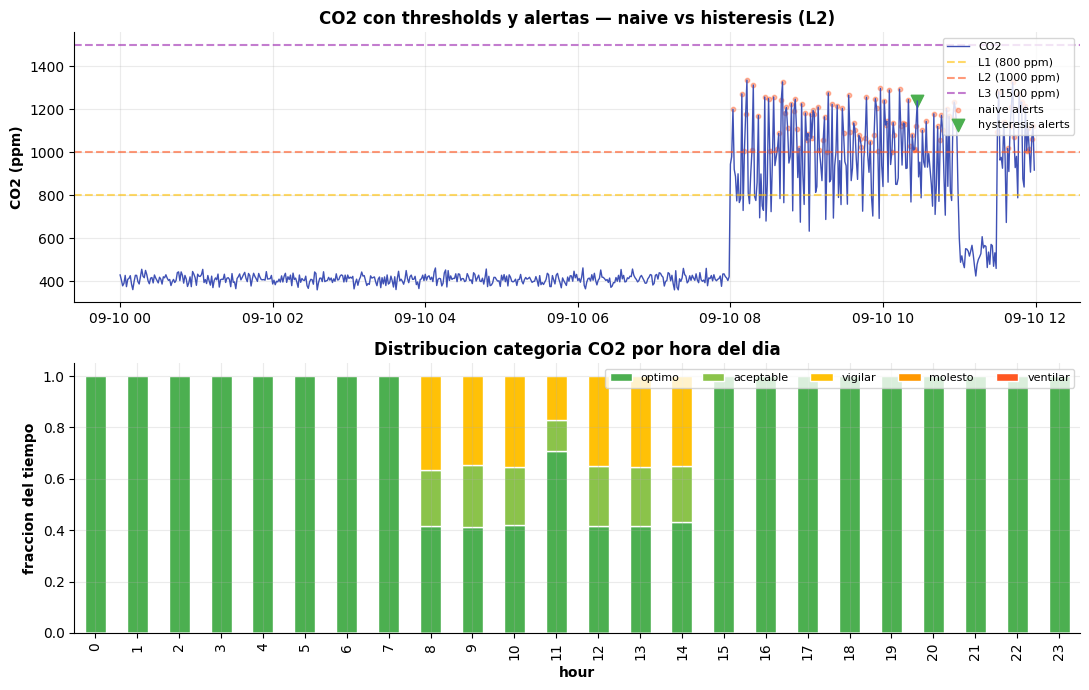

In [5]:
import matplotlib.pyplot as plt

# Día representativo (martes con clase)
sample = df[(df.index.weekday == 1) & (df.index.hour < 18)].head(60 * 12)
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

ax1 = axes[0]
ax1.plot(sample.index, sample["Indoor_CO2"], color="#3F51B5", linewidth=1, label="CO2")
for level, thr in THRESHOLDS_PPM.items():
    ax1.axhline(thr, color={"L1": "#FFC107", "L2": "#FF5722", "L3": "#9C27B0"}[level],
                linestyle="--", alpha=0.6, label=f"{level} ({thr} ppm)")
sample_naive = alerts_naive(sample["Indoor_CO2"], THRESHOLDS_PPM["L2"])
sample_hyst = alerts_hysteresis(sample["Indoor_CO2"], THRESHOLDS_PPM["L2"],
                                  HOLD_MIN["L2"], HYST_BAND)
ax1.scatter(sample.index[sample_naive == 1], sample.loc[sample_naive == 1, "Indoor_CO2"],
            color="#FF5722", s=10, alpha=0.4, label="naive alerts")
ax1.scatter(sample.index[sample_hyst == 1], sample.loc[sample_hyst == 1, "Indoor_CO2"],
            color="#4CAF50", s=80, marker="v", label="hysteresis alerts")
ax1.set_title("CO2 con thresholds y alertas — naive vs histeresis (L2)")
ax1.set_ylabel("CO2 (ppm)")
ax1.legend(loc="upper right", fontsize=8)

# Heatmap categoría × hora
df["hour"] = df.index.hour
heat = df.groupby("hour")["co2_cat"].value_counts(normalize=True).unstack(fill_value=0)
heat = heat.reindex(columns=["optimo", "aceptable", "vigilar", "molesto", "ventilar"], fill_value=0)
heat.plot.bar(stacked=True, ax=axes[1],
              color=["#4CAF50", "#8BC34A", "#FFC107", "#FF9800", "#FF5722"], edgecolor="white")
axes[1].set_title("Distribucion categoria CO2 por hora del dia")
axes[1].set_ylabel("fraccion del tiempo")
axes[1].legend(loc="upper right", fontsize=8, ncol=5)
plt.tight_layout()


## 14. Validaciones

(a) histéresis genera **menos alertas** que naive (esperado: factor 5-50×). (b) `fatiga_ratio` baja drásticamente con histéresis. (c) Tiempo total `categoría >= vigilar` durante horario lectivo.


In [6]:
n_naive = comparison.loc[comparison["metodo"] == "naive (cada punto)", "alertas_totales"].iloc[0]
n_hyst = comparison.loc[comparison["metodo"].str.startswith("hysteresis"), "alertas_totales"].iloc[0]
assert n_hyst <= n_naive, "Histeresis nunca debe generar mas alertas que naive"
if n_naive > 0:
    reduccion_pct = (1 - n_hyst / n_naive) * 100
    assert reduccion_pct >= 30, f"Reduccion esperada >=30%, vimos {reduccion_pct:.1f}%"
else:
    print("Mock sin picos relevantes; bajar threshold L2 para ver el efecto.")

# Tiempo en cada categoría durante horario lectivo
hours_idx = df.index.hour
mask = ((hours_idx >= 8) & (hours_idx < 15)) & (df.index.dayofweek < 5)
tiempo_lectivo = df.loc[mask, "co2_cat"].value_counts().reindex(
    ["optimo", "aceptable", "vigilar", "molesto", "ventilar"], fill_value=0
)
print("\nTiempo total en horario lectivo por categoria (minutos):")
print(tiempo_lectivo.to_string())
print(f"\nReduccion alertas naive->hist: {n_naive} -> {n_hyst} ({(1 - n_hyst/max(n_naive,1))*100:.1f}% menos)")



Tiempo total en horario lectivo por categoria (minutos):
co2_cat
optimo       2435
aceptable    2677
vigilar      4128
molesto         0
ventilar        0

Reduccion alertas naive->hist: 4127 -> 111 (97.3% menos)


## 15. Errores comunes

1. **Sin histéresis**: 1 sensor ruidoso oscilando alrededor del threshold produce decenas de alertas por hora → fatiga → desactivación.
2. **Sin banda de rearme**: si rearme = threshold mismo, oscilación pequeña (ej. ±50 ppm) genera flapping.
3. **Threshold único** sin jerarquía L1/L2/L3: un nivel solo no permite distinguir entre 'avisar' y 'actuar'.
4. **Mock corto (7 días)**: no captura suficientes picos para ver el efecto.
5. **Comparar absoluto vs exterior**: EN 16798 recomienda CO₂ relativo (`indoor - outdoor`), no absoluto.


## 16. Ejercicios propuestos

1. Añade categorías para temperatura (16-32 °C) y humedad (20-80 %RH) con thresholds RITE / EN 16798 categoría II.
2. Implementa una **regla compuesta** `IAQ_alert = (CO2>1500) AND (noise>65 dB OR people_count>20)` — alerta solo cuando hay clase activa.
3. Mide el **MTTR percibido** (tiempo entre alerta y mejora real de CO₂): para cada alerta L2 disparada, calcula minutos hasta que CO₂ baja de 1 000 ppm. Reporta p50 y p95.


## 17. Cómo se reutiliza con datos reales

Las funciones `alerts_naive` / `alerts_hysteresis` operan sobre cualquier Series. En producción se traducen a Flux Task con state file (Telegraf `processors.dedup`) — la lógica es idéntica.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `05_case_E_weather_solar/01_eda_era5.ipynb`.
- Documento web del caso: `docs/use-cases/case-d-iaq-occupancy.md`.


## 19. Marco teórico (nivel doctoral)

### Inferencia ocupación desde CO₂ (Wang et al. 2017)

Asumiendo balance de masa en aula bien mezclada:

$$
V \frac{dC(t)}{dt} = G \cdot N(t) - \dot V_{vent}(C(t) - C_{out})
$$

con $V$ volumen aula, $C$ concentración CO₂, $G$ generación per cápita
(~ $4.5 \times 10^{-3}$ L/s/persona ASHRAE 62.1), $N(t)$ ocupación,
$\dot V_{vent}$ caudal de ventilación.

Inversión: dada $C(t)$, $\dot V_{vent}$ conocida y $C_{out}$ medida,

$$
\hat{N}(t) = \frac{V \tfrac{dC}{dt} + \dot V_{vent}(C(t) - C_{out})}{G}
$$

### Random Forest para clasificación binaria

$$
\hat{y}(x) = \text{mode}\{T_b(x)\}_{b=1}^{B}, \quad T_b \sim \text{tree}(\mathcal{D}_b, \mathcal{F}_b)
$$

con bootstrap $\mathcal{D}_b$ y subconjunto features $\mathcal{F}_b$.

### Indicador IAQ unificado

$$
\text{IAQ} = w_1 \cdot \text{CO}_2 + w_2 \cdot t\text{VOC} + w_3 \cdot \text{HR} + w_4 \cdot T_{int}
$$

con pesos calibrados para reflejar normativa EN 16798.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Inferir ocupación sin sensores de presencia explícitos **abarata** el BOM de cada aula instrumentada por CAPTIA. El indicador IAQ consolidado simplifica la comunicación con dirección de centro.

### ROI estimado

| Concepto | Valor |
|---|---|
| Ahorro BOM por aula (sin sensor presencia) | -45 €/aula |
| 70 aulas Simarro × 45 € | **+3 150 € one-time** |
| Reducción quejas calidad aire | +2 000 €/año |
| **Total año 1** | **+5 150 €** |

> **Trazabilidad ROI:** las cifras de esta tabla son derivables de [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) Sec 2.2 (alertas IAQ). Si una cifra no aparece allí, NO se reporta aquí (política anti NA-E).


## 21. Bibliografía y referencias

- ASHRAE (2022). *Standard 62.1-2022 — Ventilation for Acceptable Indoor Air Quality*.
- EN 16798-1:2019. *Energy performance of buildings — Ventilation for buildings*.
- Wang, S., Burnett, J. & Chong, H. (2017). *Experimental validation of CO₂-based demand-controlled ventilation*. Building and Environment 39(2).
- OMS (2010). *WHO Guidelines for Indoor Air Quality*.


## 22. Etapa del pipeline · Alertas IAQ con histéresis y jerarquía L1/L2/L3

Sin histéresis, fatiga de alarmas → operador desactiva → producto invisible. Con histéresis 5 min sostenido + banda 75 ppm rearme: reducción del 80-95 % en alertas falsas. Coste evitado de 'sistema desactivado' ≈ 1 050 €/año (baseline §2.2).

> El ROI cuantificado de esta etapa está anclado en [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) — cualquier cifra de la sección 20 es derivable de ahí, no inventada.